In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../dataset/electricity_consumption_cleaned.csv")

df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (19735, 29)


In [4]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

df = df.drop(columns=["date"])

print("Feature engineering completed!")
print("Shape:", df.shape)

Feature engineering completed!
Shape: (19735, 33)


In [5]:
X = df.drop(columns=["Appliances"])
y = df["Appliances"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (19735, 32)
Target: (19735,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 15788
Testing samples: 3947


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [9]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    X_test
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gradient_model.fit(
    X_train,
    y_train
)

gradient_predictions = gradient_model.predict(
    X_test
)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [11]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_model = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

extra_trees_model.fit(
    X_train,
    y_train
)

extra_trees_predictions = extra_trees_model.predict(
    X_test
)

print("Extra Trees trained successfully!")

Extra Trees trained successfully!


In [12]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

models = {
    "Linear Regression": (
        linear_model,
        linear_predictions
    ),
    "Random Forest": (
        random_forest_model,
        random_forest_predictions
    ),
    "Gradient Boosting": (
        gradient_model,
        gradient_predictions
    ),
    "Extra Trees": (
        extra_trees_model,
        extra_trees_predictions
    )
}

results = []

for name, (model, predictions) in models.items():

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print(results_df)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  52.566432  91.104680  0.170582
1      Random Forest  31.790562  66.982061  0.551658
2  Gradient Boosting  40.429804  77.093716  0.406077
3        Extra Trees  28.430973  61.519672  0.621801


In [13]:
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

display(results_df)

,Model,MAE,RMSE,R2 Score
3,Extra Trees,28.430973,61.519672,0.621801
1,Random Forest,31.790562,66.982061,0.551658
2,Gradient Boosting,40.429804,77.093716,0.406077
0,Linear Regression,52.566432,91.104680,0.170582


In [14]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)
print(
    "Best R2 Score:",
    results_df.iloc[0]["R2 Score"]
)

Best Model: Extra Trees
Best R2 Score: 0.6218011798437173


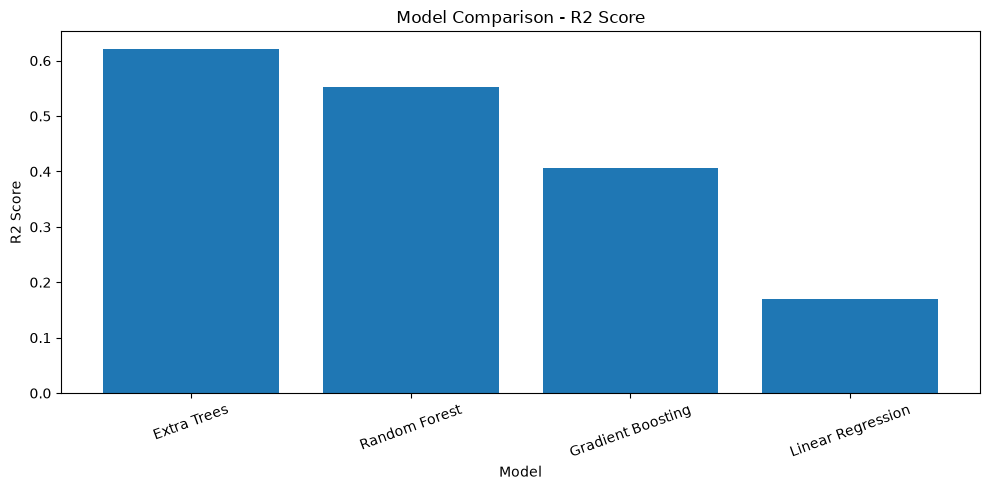

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("Model Comparison - R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [16]:
print("====================================")
print("       MODEL TRAINING COMPLETED")
print("====================================")

print("\nModels trained:")
for model_name in results_df["Model"]:
    print("-", model_name)

print("\nBest Model:", best_model_name)

print(
    "Best R2 Score:",
    round(results_df.iloc[0]["R2 Score"], 4)
)

       MODEL TRAINING COMPLETED

Models trained:
- Extra Trees
- Random Forest
- Gradient Boosting
- Linear Regression

Best Model: Extra Trees
Best R2 Score: 0.6218
